In [1]:
import pandas as pd

In [2]:
# Load dataset
data = pd.read_csv('Forbes-list-2020.csv')

In [3]:
print("Ngan Nguyen - 041154207")
df = pd.DataFrame(data)
df.describe()

Ngan Nguyen - 041154207


,NetWorth in billions,Rank,Age
count,2755.000000,2755.000000,2755.000000
mean,4.749220,1345.663521,63.014519
std,9.615358,772.669811,13.259017
min,1.000000,1.000000,18.000000
25%,1.500000,680.000000,54.000000
50%,2.300000,1362.000000,62.000000
75%,4.200000,2035.000000,72.000000
max,177.000000,2674.000000,97.000000


In [4]:
# Rename NetWorth in billions to NetWorth
df = df.rename(columns={"NetWorth in billions":"NetWorth"})
df.columns

Index(['Name', 'NetWorth', 'Country', 'Source', 'Rank', 'Age', 'Industry'], dtype='object')

### Q1: Univariate Analysis
Compute summary statistics (mean, median, min, max, std) for `NetWorth` and `Age`. Identify the youngest and oldest billionaires.

In [5]:
summary_stats = df[["NetWorth","Age"]].agg(["mean", "median", "min", "max", "std"])
print(f"Summary Statistics: \n{summary_stats.round(2)}")
print()

youngest = df.loc[df["Age"].idxmin(),"Name"]
oldest = df.loc[df["Age"].idxmax(),"Name"]
print(f"The youngest billionare: {youngest}")
print("The oldest billionare: ", oldest)

Summary Statistics: 
        NetWorth    Age
mean        4.75  63.01
median      2.30  62.00
min         1.00  18.00
max       177.00  97.00
std         9.62  13.26

The youngest billionare: Kevin David Lehmann
The oldest billionare:  Robert Kuok


### Q2: Bivariate Analysis (Categorical vs Numerical)
Compare the average `NetWorth` across different `Industries`. Which industry has the highest average net worth?

In [6]:
# Group by industry
avg_industry = df.groupby("Industry")["NetWorth"].mean().sort_values(ascending=False)
print(f"The average NetWorth across different Industries: \n{avg_industry}")
print()

top_industry, top_networth = avg_industry.index[0], avg_industry.iloc[0]
print(f"The industry has the highest average net worth: {top_industry} ({top_networth} billions)")

The average NetWorth across different Industries: 
Industry
Automotive                    6.875000
Technology                    6.730685
Telecom                       6.543750
Fashion & Retail              6.218315
Metals & Mining               5.829730
Gambling & Casinos            5.360000
Media & Entertainment         5.066316
Food & Beverage               4.702740
Diversified                   4.617553
Energy                        4.526000
Logistics                     4.165714
Finance & Investments         4.118329
Real Estate                   3.794419
Healthcare                    3.577828
Sports                        3.404167
Manufacturing                 3.383384
Service                       3.316000
Construction & Engineering    2.843182
Name: NetWorth, dtype: float64

The industry has the highest average net worth: Automotive (6.875 billions)


### Q3: Bivariate Analysis (Numerical vs Numerical)
Explore the relationship between `Age` and `NetWorth` using a scatterplot. Do younger billionaires tend to have higher net worth than older ones?

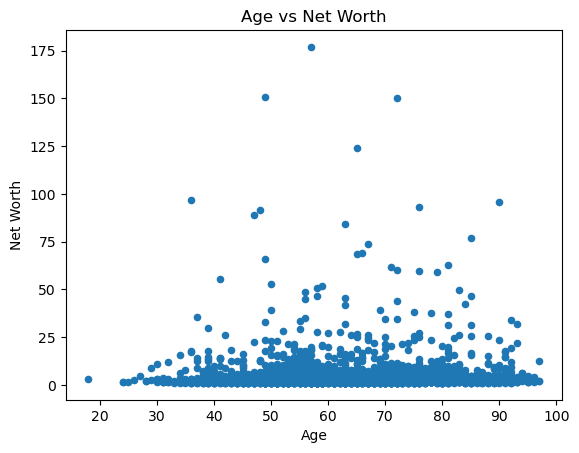

np.float64(0.035225147094842)

In [7]:

import matplotlib.pyplot as plt

# Use Scatter plot with pandas
df.plot(kind="scatter", x="Age", y="NetWorth", title = "Age vs Net Worth", xlabel = "Age", ylabel = "Net Worth")
plt.show()

df["Age"].corr(df["NetWorth"])

### Q4: Country Profile
Which Country has the highest number of billionaires in the Technology industry using crosstab?

In [8]:
#Count the number of billionares
total = pd.crosstab(df["Country"],df["Industry"])

#Choose top 1 after sorting countries by count descendingly 
top_tech = total["Technology"].sort_values(ascending = False).head(1) 
print(f"The country has the highest number of billionaires in the Technology industry: {top_tech.to_string()} billionaires")


The country has the highest number of billionaires in the Technology industry: Country
United States    140 billionaires


### Q5: Standardization using Z-score
Identify outliers based on Networth (z-score > 2 or < -2).

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#Calculate Z-score
df["NetWorth_Zscore"] = scaler.fit_transform(df[["NetWorth"]])
print(df[["NetWorth","NetWorth_Zscore"]])

#Find outliers (z-score > 2 or < -2)
outliers = df[(df["NetWorth_Zscore"] > 2) | (df["NetWorth_Zscore"] < -2)]
outliers[["NetWorth","NetWorth_Zscore"]]

      NetWorth  NetWorth_Zscore
0        177.0        17.917382
1        151.0        15.212884
2        150.0        15.108865
3        124.0        12.404367
4         97.0         9.595849
...        ...              ...
2750       1.0        -0.389991
2751       1.0        -0.389991
2752       1.0        -0.389991
2753       1.0        -0.389991
2754       1.0        -0.389991

[2755 rows x 2 columns]


,NetWorth,NetWorth_Zscore
0,177.0,17.917382
1,151.0,15.212884
2,150.0,15.108865
3,124.0,12.404367
4,97.0,9.595849
...,...,...
64,25.0,2.106469
65,24.9,2.096067
66,24.9,2.096067
67,24.6,2.064862


### Q6: Normalization
Normalize the `NetWorth` column to a 0-1 scale using min-max normalization.

In [10]:
df["NetWorth_norm"] = (df["NetWorth"] - df["NetWorth"].min()) / (df["NetWorth"].max() - df["NetWorth"].min())
print(df["NetWorth_norm"])

0       1.000000
1       0.852273
2       0.846591
3       0.698864
4       0.545455
          ...   
2750    0.000000
2751    0.000000
2752    0.000000
2753    0.000000
2754    0.000000
Name: NetWorth_norm, Length: 2755, dtype: float64


### Q7: Correlation and Covariance
Compute correlation and covariance between `Age` and `NetWorth`. What does the result suggest?

In [11]:
cor = df["Age"].corr(df["NetWorth"])
cov = df["Age"].cov(df["NetWorth"]) 

print(f"Correlation between Age and NetWorth: {cor} \nCovariance between Age and NetWorth: {cov}")

Correlation between Age and NetWorth: 0.035225147094842 
Covariance between Age and NetWorth: 4.490861007977834


The result suggests that a correlation of 0.0352 is almost zero, which means age and net worth do not show any meaningful linear connection in this dataset.
While the covariance of 4.49 is positive, which suggests net worth may rise slightly with age, but the relationship is still very weak.